# DQN training

Trains a DQN agent for the Collector env. Main changes vs first attempt:
- Richer state features (defined in `agent.py`).
- Reward shaping: bonus for moving toward an item, big bonus for collecting one, extra penalty for hitting walls.
- Use a target network and Double DQN target (use online net to pick the action, target net to score it).
- Save the best checkpoint by item count, not by reward.

In [1]:
import os, sys, time, random
from collections import deque
import numpy as np
import torch
import torch.nn as nn

from environments.collector.wrappers import CollectorGymEnv

# import preprocess and the network from agent.py so training and eval use the same setup
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from agent import preprocess, DQN_Network

SEED = 42
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


### Hyperparameters

1500 episodes is enough to get past the baseline; the rest is just polishing. The 50k buffer holds ~50 episodes of data which is plenty of variety, and γ=0.95 works well because items respawn locally so the agent only needs a fairly short horizon.

In [2]:
EPISODES = 1500
GAMMA = 0.95
LR = 1e-3
BATCH_SIZE = 128
BUFFER_SIZE = 50000
MIN_BUFFER = 2000        # don't train until buffer has this many samples
TARGET_UPDATE = 1000     # copy online -> target every N env steps

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 750000   # linear anneal over ~half of training

# reward shaping
SHAPE_BETA = 1.5      # strength of the 'move toward item' bonus
COLLECT_BONUS = 5.0   # extra reward for actually collecting an item
WALL_PENALTY = 1.0    # extra penalty for hitting a wall

EVAL_EVERY = 50

WEIGHTS_DIR = 'weights'
os.makedirs(WEIGHTS_DIR, exist_ok=True)

### Setup: env, network, target network, optimizer, replay buffer

In [3]:
env = CollectorGymEnv(numpy_output=True)

online_net = DQN_Network().to(device)
target_net = DQN_Network().to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

optimizer = torch.optim.Adam(online_net.parameters(), lr=LR)
loss_fn = nn.SmoothL1Loss()
buffer = deque(maxlen=BUFFER_SIZE)

print('Network params:', sum(p.numel() for p in online_net.parameters()))

Network params: 20228


### Reward shaping

The raw env reward is 0 on a collect, -1 on a free move, -2 on a wall hit. There's no signal at all for moving toward an item, so the agent only learns to avoid walls. The shaping adds:

- A bonus when the Manhattan distance to the nearest item decreases (penalty if it increases).
- A big one-off bonus when an item is actually collected.
- A small extra penalty for wall hits.

We skip the distance term on a collect step, because after collecting, the 'nearest item' becomes a different (farther) item and you'd get a fake penalty for a successful collection.

### Training loop

In [4]:
def nearest_item_dist(tile_map, pos):
    items = np.argwhere(tile_map == 2)
    if len(items) == 0:
        return None
    return int(np.abs(items - np.array(pos)).sum(axis=1).min())


start = time.time()
total_steps = 0
rewards_log = []
items_log = []
eval_log = []
best_eval_items = -1

for episode in range(EPISODES):
    obs, _ = env.reset()
    state = preprocess(obs['player_0'])
    ep_reward = 0.0
    ep_items = 0

    while True:
        # epsilon-greedy
        epsilon = max(EPS_END, EPS_START - (EPS_START - EPS_END) * total_steps / EPS_DECAY_STEPS)
        if np.random.rand() < epsilon:
            action = np.random.randint(4)
        else:
            with torch.no_grad():
                q = online_net(torch.FloatTensor(state).unsqueeze(0).to(device))
            action = int(q.argmax().item())

        # remember position + tile map before the step for shaping
        prev_tile_map = obs['player_0']['map_features']['tile_type']
        prev_pos = tuple(obs['player_0']['units']['position'][0])

        # random opponent during training (cheap and gives variety)
        opp_action = np.random.randint(4)
        obs, reward, terminated, truncated, info = env.step({'player_0': action, 'player_1': opp_action})
        raw_r = float(reward[0])
        next_pos = tuple(obs['player_0']['units']['position'][0])
        next_tile_map = obs['player_0']['map_features']['tile_type']
        done = bool(terminated or truncated)

        # --- reward shaping ---
        shaped_r = raw_r
        if raw_r == 0:
            # collected an item
            shaped_r += COLLECT_BONUS
            ep_items += 1
        elif raw_r <= -2:
            shaped_r -= WALL_PENALTY

        # potential-based progress bonus (skipped on collect steps to avoid the
        # 'closest item shifted' artifact)
        if raw_r != 0:
            d_prev = nearest_item_dist(prev_tile_map, prev_pos)
            d_next = nearest_item_dist(next_tile_map, next_pos)
            if d_prev is not None and d_next is not None:
                grid_scale = float(prev_tile_map.shape[0] + prev_tile_map.shape[1])
                phi_prev = -SHAPE_BETA * d_prev / grid_scale
                phi_next = -SHAPE_BETA * d_next / grid_scale
                shaped_r += GAMMA * phi_next - phi_prev

        # store transition
        next_state = preprocess(obs['player_0'])
        buffer.append((state, action, shaped_r, next_state, float(done)))
        state = next_state
        ep_reward += raw_r
        total_steps += 1

        # train
        if len(buffer) >= MIN_BUFFER:
            batch = random.sample(buffer, BATCH_SIZE)
            s, a, r, ns, d = zip(*batch)
            s = torch.FloatTensor(np.array(s)).to(device)
            a = torch.LongTensor(a).to(device)
            r = torch.FloatTensor(r).to(device)
            ns = torch.FloatTensor(np.array(ns)).to(device)
            d = torch.FloatTensor(d).to(device)

            q_curr = online_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                # use online net to pick the action, target net to score it
                # (avoids the overestimation bias of plain DQN)
                next_a = online_net(ns).argmax(dim=1, keepdim=True)
                q_next = target_net(ns).gather(1, next_a).squeeze(1)
                target = r + GAMMA * q_next * (1.0 - d)
            loss = loss_fn(q_curr, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # update target network occasionally
        if total_steps % TARGET_UPDATE == 0:
            target_net.load_state_dict(online_net.state_dict())

        if done:
            break

    rewards_log.append(ep_reward)
    items_log.append(ep_items)

    # quick eval every N episodes (greedy, random opponent — fast, no extra setup)
    if (episode + 1) % EVAL_EVERY == 0 or episode == 0:
        online_net.eval()
        obs, _ = env.reset()
        eval_items = 0
        eval_r = 0.0
        while True:
            s = preprocess(obs['player_0'])
            with torch.no_grad():
                q = online_net(torch.FloatTensor(s).unsqueeze(0).to(device))
            a = int(q.argmax().item())
            obs, rew, term, trunc, _ = env.step({'player_0': a, 'player_1': np.random.randint(4)})
            r0 = float(rew[0])
            eval_r += r0
            if r0 == 0:
                eval_items += 1
            if term or trunc:
                break
        online_net.train()
        eval_log.append((episode, eval_r, eval_items))

        elapsed = time.time() - start
        print(f'Ep {episode+1:4d}/{EPISODES} | train R {ep_reward:7.1f} items {ep_items:3d} | '
              f'eval R {eval_r:7.1f} items {eval_items:3d} | eps {epsilon:.3f} | buf {len(buffer)} | '
              f'{elapsed:5.0f}s')

        if eval_items > best_eval_items:
            best_eval_items = eval_items
            torch.save(online_net.state_dict(), os.path.join(WEIGHTS_DIR, 'dqn_best.pth'))

print('Done. Best eval items:', best_eval_items)

Ep    1/1500 | train R -1180.0 items   3 | eval R -1985.0 items   0 | eps 0.999 | buf 1000 |    11s
Ep   50/1500 | train R -1200.0 items  22 | eval R  -994.0 items   6 | eps 0.937 | buf 50000 |   436s
Ep  100/1500 | train R -1191.0 items  23 | eval R  -960.0 items  40 | eps 0.873 | buf 50000 |   838s
Ep  150/1500 | train R -1136.0 items  25 | eval R  -971.0 items  29 | eps 0.810 | buf 50000 |  1243s
Ep  200/1500 | train R -1171.0 items  32 | eval R  -949.0 items  51 | eps 0.747 | buf 50000 |  1594s
Ep  250/1500 | train R -1125.0 items  45 | eval R  -983.0 items  17 | eps 0.683 | buf 50000 |  2004s
Ep  300/1500 | train R -1100.0 items  12 | eval R  -967.0 items  33 | eps 0.620 | buf 50000 |  2424s
Ep  350/1500 | train R -1148.0 items  16 | eval R  -958.0 items  42 | eps 0.557 | buf 50000 |  2850s
Ep  400/1500 | train R -1043.0 items  60 | eval R  -993.0 items   7 | eps 0.493 | buf 50000 |  3246s
Ep  450/1500 | train R -1058.0 items  38 | eval R  -974.0 items  26 | eps 0.430 | buf 50000 

### Save final weights as `dqn.pth`

In [5]:
import shutil
best_path = os.path.join(WEIGHTS_DIR, 'dqn_best.pth')
final_path = os.path.join(WEIGHTS_DIR, 'dqn.pth')
if os.path.exists(best_path):
    shutil.copy(best_path, final_path)
    print('Saved best -> ', final_path)
else:
    torch.save(online_net.state_dict(), final_path)
    print('Saved current ->', final_path)

Saved best ->  weights\dqn.pth


### Plot

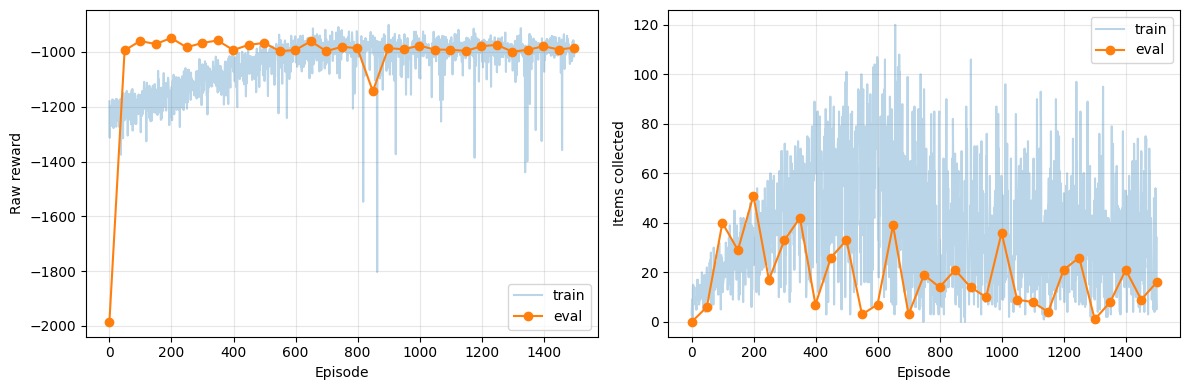

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(rewards_log, alpha=0.3, label='train')
if eval_log:
    xs = [e[0] for e in eval_log]
    ax[0].plot(xs, [e[1] for e in eval_log], 'o-', label='eval')
ax[0].set_xlabel('Episode'); ax[0].set_ylabel('Raw reward'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(items_log, alpha=0.3, label='train')
if eval_log:
    ax[1].plot(xs, [e[2] for e in eval_log], 'o-', label='eval')
ax[1].set_xlabel('Episode'); ax[1].set_ylabel('Items collected'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()